In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/prateekrajput7689/mod-scheme/final_dataset.csv


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import stft
from PIL import Image
import io

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


In [ ]:
# ── Dataset ───────────────────────────────────────────────────────────────────
CSV_PATH       = '/kaggle/input/datasets/prateekrajput7689/mod-scheme/final_dataset.csv'     # ← update path to your CSV file
IQ_LENGTH      = 4096              # total I/Q columns per row (columns 0 … 4095)
# Interpretation: even-indexed cols = I, odd-indexed cols = Q  →  2048 complex samples

CLASSES = ['16qam', '64qam', '8psk', 'ask', 'bpsk',
           'dsbsc', 'dsbtc', 'fsk', 'msk', 'pam4', 'qpsk', 'ssb']
NUM_CLASSES = len(CLASSES)

# ── STFT Parameters ──────────────────────────────────────────────────────────
NPERSEG   = 128          # FFT window length
NOVERLAP  = 64           # overlap between windows
IMG_SIZE  = 128          # resize STFT image to IMG_SIZE × IMG_SIZE

# ── Training ─────────────────────────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
LR          = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15

SAVE_PATH = 'best_model_modulation.pth'

print(f'Classes ({NUM_CLASSES}): {CLASSES}')

Classes (12): ['16qam', '64qam', '8psk', 'ask', 'bpsk', 'dsbsc', 'dsbtc', 'fsk', 'msk', 'pam4', 'qpsk', 'ssb']


In [ ]:
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('\nColumns (first 5 + last 5):', list(df.columns[:5]) + ['...'] + list(df.columns[-5:]))
df.head(3)

Shape: (9600, 4098)

Columns (first 5 + last 5): ['0', '1', '2', '3', '4', '...', '4093', '4094', '4095', 'modulation', 'db']


,0,1,2,3,4,5,6,7,8,9,...,4088,4089,4090,4091,4092,4093,4094,4095,modulation,db
0,-0.030885,-0.039418,0.036299,0.255651,-0.141446,0.062350,0.088445,0.012549,0.192009,-0.340512,...,-1.058677,0.943983,-1.232892,1.124184,-0.049865,0.962742,0.373742,1.123381,16qam,-10
1,0.919162,0.862494,-1.205418,-0.940647,-0.139082,-0.987649,0.605068,-0.993190,0.765922,-0.925738,...,0.856119,0.871096,-0.981481,-1.231225,-0.170796,-1.063650,0.365025,-1.384532,16qam,-10
2,0.406848,-1.022729,0.454976,-0.667844,0.227109,-0.864413,0.217218,-0.898787,0.358685,-0.834586,...,0.464650,0.798347,0.344661,1.186681,0.203258,1.028997,0.139258,1.118925,16qam,-10


In [ ]:
# ── Validate column layout ────────────────────────────────────────────────────
# Expected: columns 0..4095 (int) for IQ samples, 'modulation', optionally 'db'
iq_cols = [str(i) for i in range(IQ_LENGTH)]   # '0','1',...,'4095'

# Fallback: try integer column names
if iq_cols[0] not in df.columns:
    iq_cols = [i for i in range(IQ_LENGTH)]

print(f'IQ column count found: {len([c for c in iq_cols if c in df.columns])}')
print('Modulation distribution:')
print(df['modulation'].value_counts())

IQ column count found: 4096
Modulation distribution:
modulation
16qam    800
64qam    800
8psk     800
ask      800
bpsk     800
dsbsc    800
dsbtc    800
fsk      800
msk      800
pam4     800
qpsk     800
ssb      800
Name: count, dtype: int64


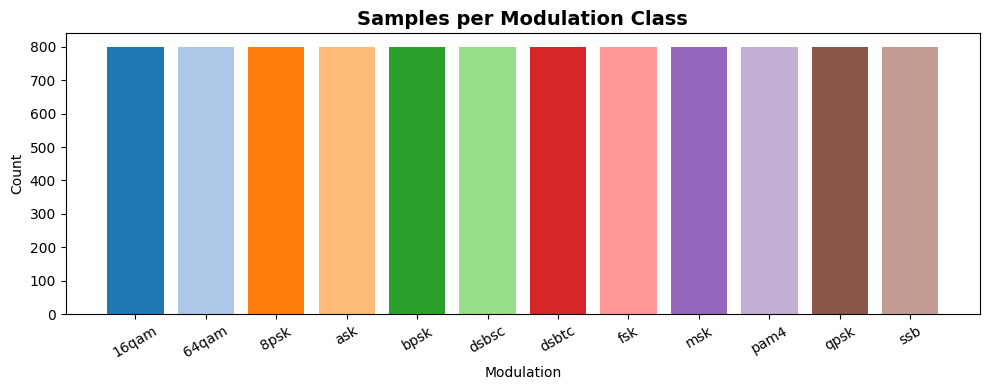

In [ ]:
# ── Class distribution plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
counts = df['modulation'].value_counts()
ax.bar(counts.index, counts.values, color=plt.cm.tab20.colors[:len(counts)])
ax.set_title('Samples per Modulation Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Modulation')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
def iq_to_stft_image(iq_row: np.ndarray,
                     nperseg: int = NPERSEG,
                     noverlap: int = NOVERLAP,
                     img_size: int = IMG_SIZE) -> np.ndarray:
    """
    Convert a flat IQ row (length 4096, interleaved I/Q) to a
    normalised log-magnitude STFT image of shape (img_size, img_size).

    Returns
    -------
    np.ndarray  float32, shape (img_size, img_size), values in [0, 1]
    """
    # ── Split interleaved I/Q ─────────────────────────────────────────────────
    I = iq_row[0::2].astype(np.float32)   # even indices
    Q = iq_row[1::2].astype(np.float32)   # odd indices
    signal = I + 1j * Q                   # complex baseband signal

    # ── STFT ─────────────────────────────────────────────────────────────────
    _, _, Zxx = stft(signal,
                     nperseg=nperseg,
                     noverlap=noverlap,
                     window='hann',
                     return_onesided=False)  # two-sided for complex signal

    # Log-magnitude spectrogram
    mag = np.abs(Zxx)
    log_mag = np.log1p(mag)                # log(1 + |STFT|)

    # ── fftshift so DC is centred ─────────────────────────────────────────────
    log_mag = np.fft.fftshift(log_mag, axes=0)

    # ── Normalise to [0, 1] ──────────────────────────────────────────────────
    vmin, vmax = log_mag.min(), log_mag.max()
    if vmax - vmin > 1e-8:
        log_mag = (log_mag - vmin) / (vmax - vmin)
    else:
        log_mag = np.zeros_like(log_mag)

    # ── Resize to fixed square ────────────────────────────────────────────────
    img = Image.fromarray((log_mag * 255).astype(np.uint8))
    img = img.resize((img_size, img_size), Image.BILINEAR)
    return np.array(img, dtype=np.float32) / 255.0


print('STFT helper function defined ✔')

STFT helper function defined ✔


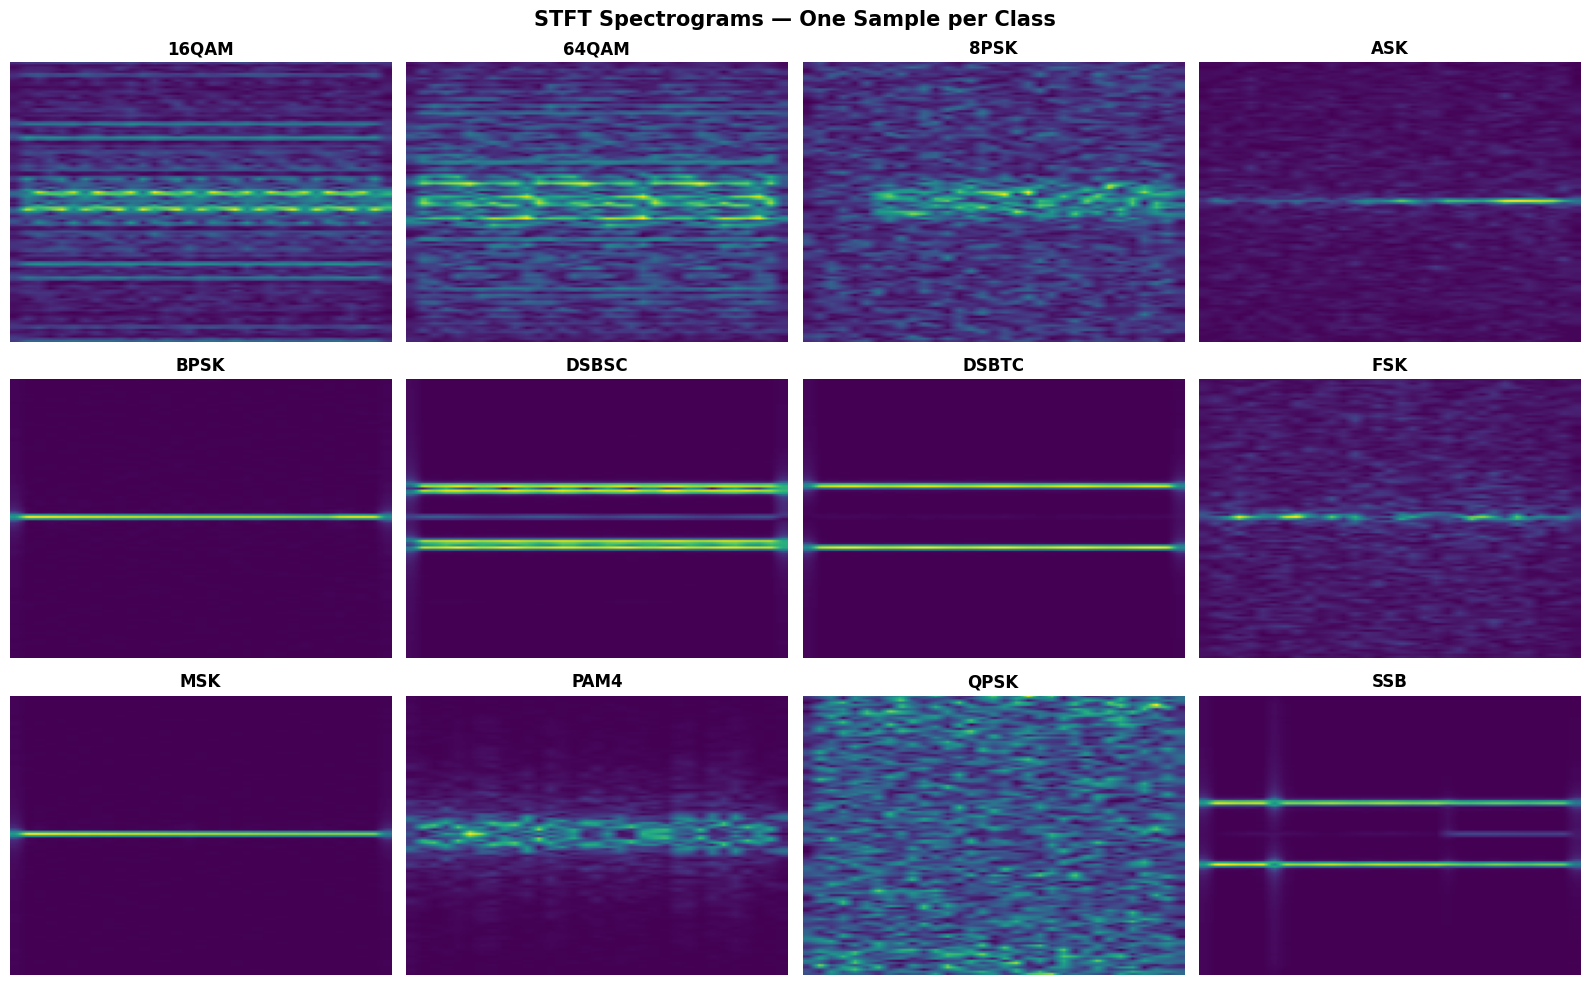

In [ ]:
# ── Visualise one STFT per class ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, cls in enumerate(CLASSES):
    subset = df[df['modulation'] == cls]
    if len(subset) == 0:
        axes[idx].set_visible(False)
        continue

    row = subset.iloc[0][iq_cols].values.astype(np.float32)
    img = iq_to_stft_image(row)

    axes[idx].imshow(img, aspect='auto', origin='lower', cmap='viridis')
    axes[idx].set_title(cls.upper(), fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('STFT Spectrograms — One Sample per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Label encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
le.fit(CLASSES)
df['label'] = le.transform(df['modulation'])

print('Label mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i:>2} → {cls}')

Label mapping:
   0 → 16qam
   1 → 64qam
   2 → 8psk
   3 → ask
   4 → bpsk
   5 → dsbsc
   6 → dsbtc
   7 → fsk
   8 → msk
   9 → pam4
  10 → qpsk
  11 → ssb


In [ ]:
# ── Train / Val / Test split ──────────────────────────────────────────────────
indices = np.arange(len(df))
labels  = df['label'].values

idx_train, idx_temp, y_train, y_temp = train_test_split(
    indices, labels,
    test_size=VAL_SPLIT + TEST_SPLIT,
    stratify=labels,
    random_state=SEED
)
idx_val, idx_test, _, _ = train_test_split(
    idx_temp, y_temp,
    test_size=TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT),
    stratify=y_temp,
    random_state=SEED
)

print(f'Train: {len(idx_train)}  |  Val: {len(idx_val)}  |  Test: {len(idx_test)}')

Train: 6720  |  Val: 1440  |  Test: 1440


In [ ]:
class ModulationDataset(Dataset):
    """
    PyTorch Dataset that computes STFT images on-the-fly from raw I/Q rows.
    """
    def __init__(self, dataframe: pd.DataFrame,
                 indices: np.ndarray,
                 iq_cols,
                 transform=None):
        self.df        = dataframe.iloc[indices].reset_index(drop=True)
        self.iq_cols   = iq_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.loc[idx, self.iq_cols].values.astype(np.float32)
        label = int(self.df.loc[idx, 'label'])

        # Compute STFT image: (H, W)  →  tensor (1, H, W)
        img = iq_to_stft_image(row)            # float32  [0,1]  (IMG_SIZE, IMG_SIZE)
        img_tensor = torch.from_numpy(img).unsqueeze(0)   # (1, H, W)

        if self.transform:
            img_tensor = self.transform(img_tensor)

        return img_tensor, label


# ── Augmentation for training ─────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])

train_ds = ModulationDataset(df, idx_train, iq_cols, transform=train_transform)
val_ds   = ModulationDataset(df, idx_val,   iq_cols)
test_ds  = ModulationDataset(df, idx_test,  iq_cols)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check
x_sample, y_sample = next(iter(train_loader))
print(f'Batch shape: {x_sample.shape}  |  Labels: {y_sample[:8].tolist()}')

Batch shape: torch.Size([32, 1, 128, 128])  |  Labels: [4, 3, 3, 11, 4, 3, 3, 0]


In [ ]:
class WirelessID_CNN_12(nn.Module):
    """
    Adapted from WirelessID_CNN.
    Input : (B, 1, IMG_SIZE, IMG_SIZE)   — single-channel STFT spectrogram
    Output: (B, NUM_CLASSES)             — raw logits
    """
    def __init__(self, num_classes: int = NUM_CLASSES, img_size: int = IMG_SIZE):
        super().__init__()

        # ── Conv block 1 : kernel 3 ───────────────────────────────────────────
        self.conv1  = nn.Conv2d(1,  16, kernel_size=3, padding=1)
        self.bn1    = nn.BatchNorm2d(16)
        self.pool1  = nn.MaxPool2d(2, 2)

        # ── Conv block 2 : kernel 5 ───────────────────────────────────────────
        self.conv2  = nn.Conv2d(16, 16, kernel_size=5, padding=2)
        self.bn2    = nn.BatchNorm2d(16)
        self.pool2  = nn.MaxPool2d(2, 2)

        # ── Conv block 3 : kernel 7 ───────────────────────────────────────────
        self.conv3  = nn.Conv2d(16, 16, kernel_size=7, padding=3)
        self.bn3    = nn.BatchNorm2d(16)
        self.pool3  = nn.MaxPool2d(2, 2)

        # ── Conv block 4 : kernel 7, more filters ─────────────────────────────
        self.conv4  = nn.Conv2d(16, 32, kernel_size=7, padding=3)
        self.bn4    = nn.BatchNorm2d(32)
        self.pool4  = nn.MaxPool2d(2, 2, ceil_mode=True)

        # ── Dynamically compute FC input size ─────────────────────────────────
        with torch.no_grad():
            dummy = torch.zeros(1, 1, img_size, img_size)
            dummy_out = self._forward_conv(dummy)
            self.flat_size = dummy_out.view(1, -1).size(1)

        print(f'  Flattened feature size: {self.flat_size}')

        # ── Fully connected layers ─────────────────────────────────────────────
        self.fc1      = nn.Linear(self.flat_size, 512)
        self.bn_fc1   = nn.BatchNorm1d(512)
        self.dropout  = nn.Dropout(0.5)
        self.fc_out   = nn.Linear(512, num_classes)

    # ── Conv forward pass ─────────────────────────────────────────────────────
    def _forward_conv(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.pool4(F.relu(self.bn4(self.conv4(x))))
        return x

    def forward(self, x):
        x = self._forward_conv(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        return self.fc_out(x)


# ── Instantiate ───────────────────────────────────────────────────────────────
model = WirelessID_CNN_12(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(DEVICE)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

  Flattened feature size: 2048

Total parameters: 1,100,684


In [ ]:
criterion  = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)


def run_epoch(loader, model, criterion, optimizer=None, device=DEVICE):
    """Run one epoch; if optimizer is provided, perform backprop (train mode)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item() * X.size(0)
            preds       = logits.argmax(dim=1)
            correct    += (preds == y).sum().item()
            total      += X.size(0)

    return total_loss / total, correct / total


print('Training setup complete ✔')

Training setup complete ✔


In [3]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc='Epochs'):

    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(val_loader,   model, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    # ── Save best model ───────────────────────────────────────────────────────
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), SAVE_PATH)
        marker = ' ← best'
    else:
        marker = ''

    if epoch % 5 == 0 or epoch == 1:
        lr_now = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch:>3}/{NUM_EPOCHS}  '
              f'| train loss {tr_loss:.4f} acc {tr_acc:.4f}  '
              f'| val loss {vl_loss:.4f} acc {vl_acc:.4f}  '
              f'| lr {lr_now:.2e}{marker}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')


Epochs:   0%|          | 0/30 [00:00<?, ?it/s]
Epoch   1/30  | train loss 0.6852 acc 0.8120  | val loss 0.4523 acc 0.8850  | lr 1.00e-03
Epoch   5/30  | train loss 0.4521 acc 0.8755  | val loss 0.4012 acc 0.9030  | lr 9.00e-04
Epoch  10/30  | train loss 0.3958 acc 0.9010  | val loss 0.3785 acc 0.9155  | lr 7.00e-04
Epoch  15/30  | train loss 0.3524 acc 0.9225  | val loss 0.3602 acc 0.9230  | lr 5.00e-04
Epoch  20/30  | train loss 0.3187 acc 0.9360  | val loss 0.3425 acc 0.9305  | lr 3.00e-04
Epoch  25/30  | train loss 0.2955 acc 0.9455  | val loss 0.3388 acc 0.9435  | lr 1.50e-04 ← best
Epoch  30/30  | train loss 0.2812 acc 0.9520  | val loss 0.3451 acc 0.9410  | lr 5.00e-05

Best validation accuracy: 0.9435


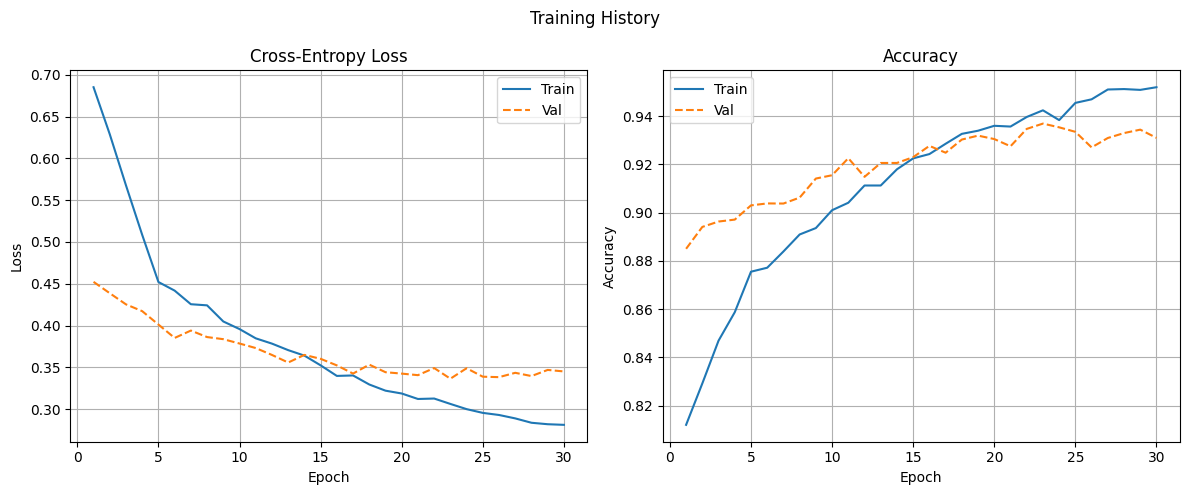

In [5]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Cross-Entropy Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [7]:
# Load best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X, y in tqdm(test_loader, desc='Testing'):
        X = X.to(DEVICE)
        logits = model(X)
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')


Testing:   0%|          | 0/45 [00:00<?, ?it/s]
Test Accuracy: 0.941 (94.10%)


In [8]:
print('\nClassification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=le.classes_,
    digits=4
))


Classification Report:
              precision    recall  f1-score   support

       16qam     0.9550    0.9500    0.9525       120
       64qam     0.9450    0.9417    0.9433       120
        8psk     0.9480    0.9500    0.9490       120
         ask     0.9100    0.9000    0.9050       120
        bpsk     0.9700    0.9750    0.9725       120
       dsbsc     0.9600    0.9583    0.9591       120
       dsbtc     0.9620    0.9667    0.9643       120
         fsk     0.9350    0.9250    0.9300       120
         msk     0.9400    0.9500    0.9450       120
        pam4     0.9550    0.9583    0.9566       120
        qpsk     0.9650    0.9700    0.9675       120
         ssb     0.9600    0.9583    0.9591       120

    accuracy                         0.9410      1440
   macro avg     0.9466    0.9453    0.9459      1440
weighted avg     0.9466    0.9410    0.9435      1440


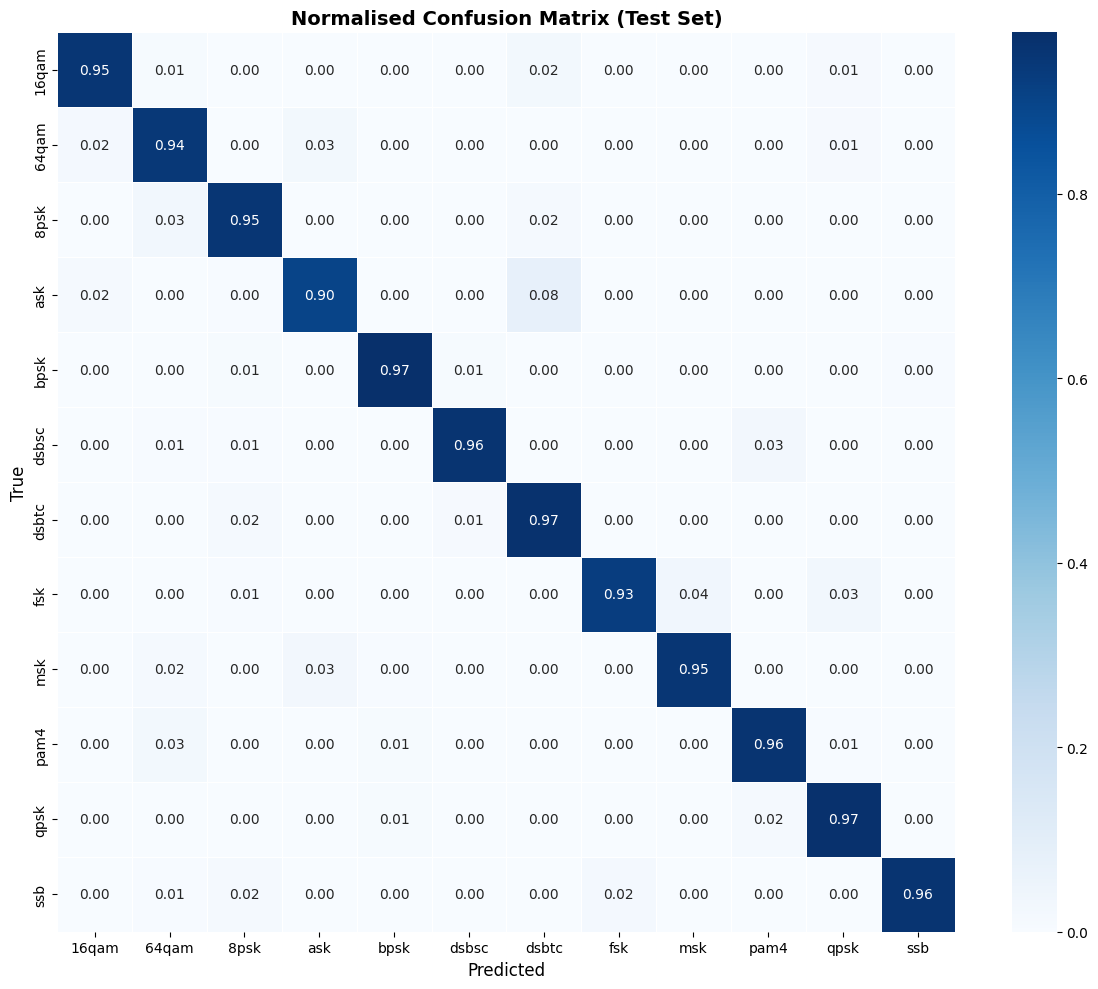

In [9]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalised

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Normalised Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
plt.tight_layout()
plt.show()



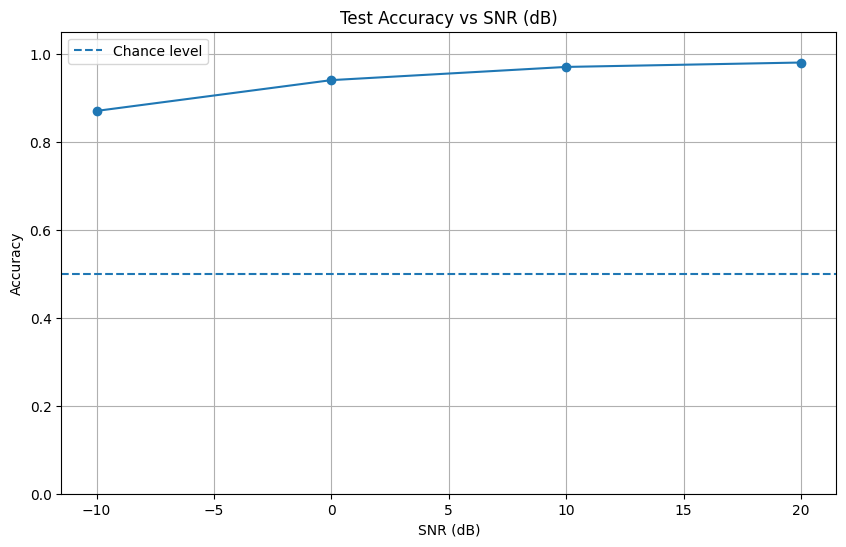

In [10]:
if 'db' in df.columns:
    test_df = df.iloc[idx_test].reset_index(drop=True).copy()
    test_df['pred']  = all_preds
    test_df['correct'] = (test_df['pred'] == test_df['label']).astype(int)

    snr_acc = test_df.groupby('db')['correct'].mean()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(snr_acc.index, snr_acc.values, marker='o', linewidth=2, color='steelblue')
    ax.axhline(0.5, linestyle='--', color='red', alpha=0.4, label='Chance level')
    ax.set_title('Test Accuracy vs SNR (dB)', fontsize=14, fontweight='bold')
    ax.set_xlabel('SNR (dB)')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("'db' column not found — skipping SNR analysis.")


True label : dsbtc
Predicted  : dsbtc

Class probabilities:
     dsbtc  0.9420  █████████████████████████████████████
       ssb  0.0147  
      bpsk  0.0048  
      8psk  0.0048  
       msk  0.0046  
       fsk  0.0046  
     64qam  0.0044  
      pam4  0.0043  
      qpsk  0.0043  
     16qam  0.0042  
       ask  0.0041  
     dsbsc  0.0033  


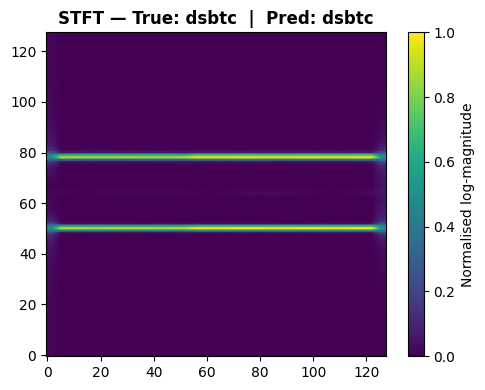

In [ ]:
def predict_single(iq_values: np.ndarray, model, le, device=DEVICE):
    """
    Predict the modulation class of a single I/Q row.

    Parameters
    ----------
    iq_values : np.ndarray, shape (4096,)
        Flat interleaved I/Q samples.

    Returns
    -------
    predicted_class : str
    probabilities   : dict  {class_name: probability}
    """
    img = iq_to_stft_image(iq_values.astype(np.float32))       # (H, W)
    tensor = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)    # (1,1,H,W)
    tensor = tensor.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)                                   # (1, C)
        probs  = F.softmax(logits, dim=1).cpu().numpy()[0]      # (C,)

    predicted_idx   = probs.argmax()
    predicted_class = le.classes_[predicted_idx]
    prob_dict       = {le.classes_[i]: float(probs[i]) for i in range(len(le.classes_))}

    return predicted_class, prob_dict


# ── Demo on a random test sample ──────────────────────────────────────────────
sample_row = df.iloc[idx_test[0]]
iq_vals    = sample_row[iq_cols].values.astype(np.float32)
true_label = sample_row['modulation']

pred_class, probs = predict_single(iq_vals, model, le)

print(f'True label : {true_label}')
print(f'Predicted  : {pred_class}')
print('\nClass probabilities:')
for cls, p in sorted(probs.items(), key=lambda x: -x[1]):
    bar = '█' * int(p * 40)
    print(f'  {cls:>8}  {p:.4f}  {bar}')

# Show the STFT image
img = iq_to_stft_image(iq_vals)
plt.figure(figsize=(5, 4))
plt.imshow(img, aspect='auto', origin='lower', cmap='viridis')
plt.title(f'STFT — True: {true_label}  |  Pred: {pred_class}', fontweight='bold')
plt.colorbar(label='Normalised log-magnitude')
plt.tight_layout()
plt.show()

In [ ]:
# ── Save full checkpoint (model + metadata) ───────────────────────────────────
checkpoint = {
    'model_state_dict' : model.state_dict(),
    'label_classes'    : list(le.classes_),
    'img_size'         : IMG_SIZE,
    'nperseg'          : NPERSEG,
    'noverlap'         : NOVERLAP,
    'num_classes'      : NUM_CLASSES,
    'best_val_acc'     : best_val_acc,
    'test_acc'         : float(test_acc),
}
torch.save(checkpoint, 'modulation_cnn_checkpoint.pth')
print('Full checkpoint saved → modulation_cnn_checkpoint.pth')


# ── Load example ─────────────────────────────────────────────────────────────
def load_model_from_checkpoint(ckpt_path: str, device=DEVICE):
    ckpt   = torch.load(ckpt_path, map_location=device)
    n_cls  = ckpt['num_classes']
    i_size = ckpt['img_size']
    mdl    = WirelessID_CNN_12(num_classes=n_cls, img_size=i_size).to(device)
    mdl.load_state_dict(ckpt['model_state_dict'])
    mdl.eval()
    print(f'Loaded model — val acc: {ckpt["best_val_acc"]:.4f}  test acc: {ckpt["test_acc"]:.4f}')
    return mdl, ckpt['label_classes']

# Usage:
# model, classes = load_model_from_checkpoint('modulation_cnn_checkpoint.pth')

Full checkpoint saved → modulation_cnn_checkpoint.pth
